# **Altair Assignment 1**

Adapted from Licia He, Elsie Lee, and Eytan Adar and Altair Documentation

We are going to recreate one of the visualizations from the New York Times Article [How Much It Costs to Drive an E.V. and a Gas Car in Every State](https://www.nytimes.com/2025/10/08/upshot/ev-versus-gas-car-comparison-cost.html). Your goal is to come up with 2 visualizations:

1.   Recreate 1 visualization from the original article as closely as possible using Altair
2.   Design and implement a new visualization that provides additional insights about the topic not covered in the article

## Assignment Instructions
* Save the altair-assignment-1.ipynb file, rename it, and submit the modified file (use your username in the name).
* Run every cell (do Runtime -> Restart and run all to make sure you have a clean working version), print to pdf, submit the pdf file.
* For each visualization, we will ask you to write down a "Grammar of Graphics" plan first (basically a description of what you'll code).
* If you end up stuck, show us your work by including links (URLs) that you have searched for. You'll get partial credit for showing your work in progress.

We encourage you to go through the Altair tutorials before next week:

* [UW Course](https://github.com/uwdata/visualization-curriculum)
* [Altair tutorial](https://github.com/altair-viz/altair-tutorial)

## Resources

* [Altair Documentation](https://altair-viz.github.io/index.html)
* [Markdown Cheatsheet](https://www.markdownguide.org/cheat-sheet/)
* [Pandas DataFrame Introduction](https://pandas.pydata.org/docs/user_guide/10min.html)



In [3]:
#package that converts vega-lite charts into static images
%pip install vl-convert-python

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
# imports we will use
import altair as alt
import pandas as pd

# Data Preparation

First, let's load and examine our data. This dataset contains state-level electricity and gas prices.

In [2]:
#Load the state energy prices data
datasetURL = "https://raw.githubusercontent.com/yellstales/si649public/refs/heads/main/altair01assignment/state_energy_prices.csv"
energyDF = pd.read_csv(datasetURL)

# Display first few ros of the data
energyDF.head()

,state,elec,gas,ratio,dc_price
0,Alabama,0.1609,2.78,0.0579,0.47
1,Alaska,0.2608,3.76,0.0694,0.59
2,Arizona,0.1576,3.18,0.0496,0.55
3,Arkansas,0.1315,2.79,0.0471,0.65
4,California,0.3503,4.50,0.0778,0.60


The dataset contains:
* `state`: State name
* `elec`: Electricity price (per kWh)
* `gas`: Gas price (per gallon)
* `ratio`: Electricity to gas price ratio
* `dc_price`: DC fast charging price (per KWh)

From the article we can also derive vehicle efficiency data:
* Electric vehicles: 0.3 kWh per mile
* Gas car (standard): 25 miles per gallon
* Gas car (hybrid): 50 miles per gallon

In [4]:
#vehicle efficiency constants
ev_efficiency=0.3 #kWh per mile
gas_efficiency = 25 #miles per gallon
hybrid_efficiency = 50 #miles per gallon

#calculate national averages for electricity / gas / dc charge cost
avg_elec = energyDF['elec'].mean()
avg_gas = energyDF['gas'].mean()
avg_dc = energyDF['dc_price'].mean()

#calculate costs for 100 miles
distance = 100
cost_ev_home = (distance * ev_efficiency) * avg_elec
cost_hybrid = (distance / hybrid_efficiency) * avg_gas
cost_gas_standard = (distance / gas_efficiency) * avg_gas
cost_ev_fast = (distance * ev_efficiency) * avg_dc

viz_data = pd.DataFrame([
    {'vehicle_type': 'Electric car (home charging)', 'cost': cost_ev_home, 'category': 'electric'},
    {'vehicle_type': 'Gas car, hybrid', 'cost': cost_hybrid, 'category': 'gas'},
    {'vehicle_type': 'Gas car, standard', 'cost': cost_gas_standard, 'category': 'gas'},
    {'vehicle_type': 'Electric car (fast charging)', 'cost': cost_ev_fast, 'category': 'electric'}
])

viz_data

,vehicle_type,cost,category
0,Electric car (home charging),5.456647,electric
1,"Gas car, hybrid",6.289804,gas
2,"Gas car, standard",12.579608,gas
3,Electric car (fast charging),15.641176,electric


# Part 1: Recreate Visualization

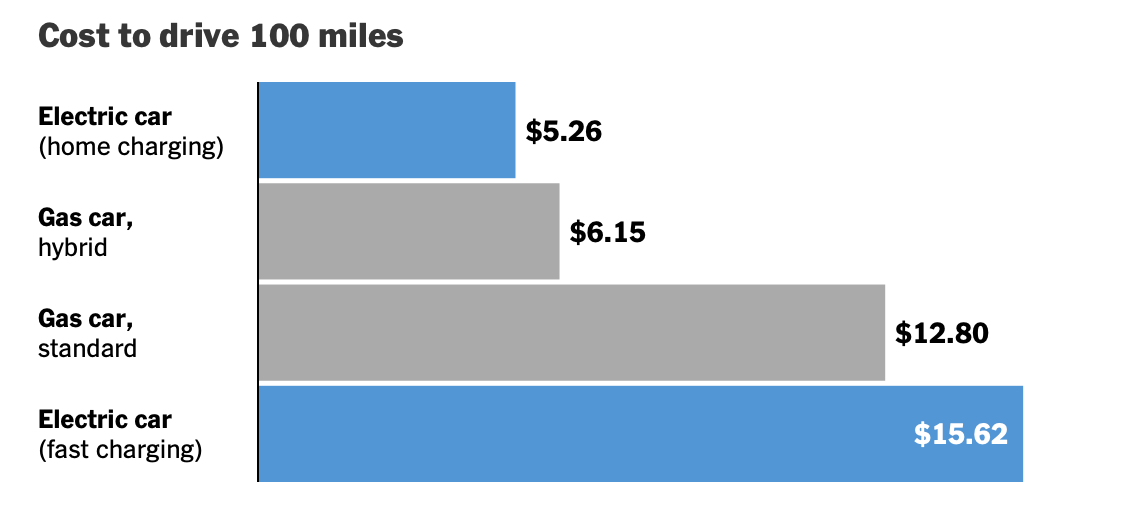

Requirements:
*   Horizontal bars for each vehicle type
*   Blue color for electric vehicles (identify correct hex value)
*   Gray color for gas vehicles (identify correct hex value)
*   Cost labeled at the end of each bar
*   Clear title
*   Correct ordering



## Step 1: Grammar of Graphics Plan (required)

TODO: fill out your plan for visualization
* Data Name: *viz_data*
* Mark type: *TODO: bar (to represent the cost magnitude) and text (to display the exact values at the end of each bar)
* Encoding Specification:
    * x : cost : Quantitative (Q)
    * y : vehicle_type : Nominal (N)
    * color : category : Nominal (N)
    * text : cost : Quantitative (Q)

## Step 2: Create your chart

Please use the checkpoints below to work through the problem step-by-step. Search for "TODO" to find cells that need your edits.

### Checkpoint 1: Basic horizontal bar chart with a title

Create a basic horizontal bar chart showing vehicle types and costs. Your chart should show horizontal bars with the title, but won't have colors, labels or correct order yet

In [19]:
# TODO: Create a basic horizontal bar chart with a title
# Map vehicle cost to x axis and vehicle type to y axis
# Specify data types for encodings
# Add the title
# Create a basic horizontal bar chart
chart = alt.Chart(viz_data).mark_bar().encode(
    x='cost:Q',           # Quantitative data type for numerical values
    y='vehicle_type:N'    # Nominal data type for categorical labels
).properties(
    title='Cost to drive 100 miles'
)

chart.display()

alt.Chart(...)

### Checkpoint 2: Add colors based on vehicle category

Now add colors to distinguish electric vehicles (blue) from gas vehicles (gray).

**Hint: In encodings use color channel following way:**


```
color=alt.Color('COLUMN:DATA_TYPE').scale(
  domain=['CAT1', 'CAT2'],
  range=['#HEXVALUE1', '#HEXVALUE2']
)
```
Read more in [Altair documentation](https://altair-viz.github.io/user_guide/customization.html#color-domain-and-range)




In [20]:
# TODO: Add color encoding
# Copy your code from checkpoint 1
# Add color encoding with custom colors
# Create the horizontal bar chart with custom colors
chart = alt.Chart(viz_data).mark_bar().encode(
    x='cost:Q',
    y='vehicle_type:N',
    color=alt.Color('category:N').scale(
        domain=['electric', 'gas'],
        range=['#3498db', '#bdc3c7']  # Blue for electric, Gray for gas
    )
).properties(
    title='Cost to drive 100 miles'
)

chart.display()

alt.Chart(...)

**Original visualization doesn't have a legend, try to find a way to remove it from the visualization above:D **

### Checkpoint 3: Add cost label next to the bars

To add the label next to the bar we need to create a second chart using `mark_text()` and layer on top of the existing bar chart. You can achieve that using the following process:

1. Refactor the code from checkpoint 2 to derive base:
```
base = alt.Chart(DATA).encode(X, Y).properties(PROPERTIES)
```
2. Create bar chart applying `mark_bar()` to the base:
```
bars = base.mark_bar().encode(COLOR)
```
3. Create text chart applying `mark_text()` to the base:
```
text = base.mark_text(
  align='left'
  dx=2
  fontWeight='someweight'
).encode(alt.Text(ENCODING).format('$.2f'))
```
4. Layer the charts using `+`

Refer to [Altair documentation](https://altair-viz.github.io/gallery/bar_chart_with_labels.html) for some hints

In [21]:
#TODO: Add cost label next to the bars
# 1. Refactor the code to create a base chart
base = alt.Chart(viz_data).encode(
    x=alt.X('cost:Q', title=None, axis=None), # Hide x-axis for that clean look
    y=alt.Y('vehicle_type:N', title=None, sort=None)
).properties(
    title='Cost to drive 100 miles',
    width=400
)

# 2. Create bar chart by applying mark_bar() and color encoding to the base
bars = base.mark_bar().encode(
    color=alt.Color('category:N').scale(
        domain=['electric', 'gas'],
        range=['#3498db', '#bdc3c7']
    ).legend(None) # Remove legend to match the reference
)

# 3. Create text chart by applying mark_text() and text encoding to the base
text = base.mark_text(
    align='left',
    dx=5,           # Shifting text slightly to the right of the bar
    fontWeight='bold'
).encode(
    text=alt.Text('cost:Q', format='$.2f') # Format as currency with 2 decimals
)

# 4. Layer the charts using the + operator
final_chart = (bars + text).configure_view(
    strokeWidth=0  # Remove the chart border
)

final_chart.display()

alt.LayerChart(...)

### Checkpoint 4: Remove grid and border, and make axis labels bold

1. Remove the grid using method chaining:
```
configure_axis(
  grid=False
)
```
2. Remove borders using method chaining:
```
configure_view(
  stroke=None
)
```
3. Make axis labels bold using method chaining:
```
configure_axis(
    labelFontWeight='someweight'
)
```

In [22]:
# TODO: Remove grid and border
# Copy code from checkpoint 2
# Use method chaining to remove borders and grid
# 1. Combine bars and text into a layered chart
final_chart = (bars + text)

# 2. Chain the configuration methods
final_chart = final_chart.configure_axis(
    grid=False,           # Remove background grid lines
    labelFontWeight='bold' # Make y-axis labels bold
).configure_view(
    stroke=None            # Remove the outer chart border/box
)

final_chart.display()

alt.LayerChart(...)

### Checkpoint 5: Remove X axis and Y axis title

To remove axes, we need to change encoding syntax from
```
x='cost:Q'
```
to
```
alt.X('cost:Q')
```
after that you can chain the following to remove the axis completely
```
.axis(None)
```
or if you only want to remove the title of the axis, you may use
```
.title(None)
```









In [23]:
# TODO: Remove axes
# Copy the code from checkpoint 3
# Make necessary changes to remove the X axes completely, and title of the Y axis
# 1. Update the base chart to remove the x-axis and y-axis title
base = alt.Chart(viz_data).encode(
    x=alt.X('cost:Q').axis(None),           # Removes the entire x-axis (ticks, labels, and title)
    y=alt.Y('vehicle_type:N').title(None)   # Keeps the vehicle labels but removes the "vehicle_type" title
).properties(
    title='Cost to drive 100 miles',
    width=400
)

# 2. Re-apply the bar and text marks (they inherit the new base settings)
bars = base.mark_bar().encode(
    color=alt.Color('category:N').scale(
        domain=['electric', 'gas'],
        range=['#3498db', '#bdc3c7']
    ).legend(None)
)

text = base.mark_text(
    align='left',
    dx=5,
    fontWeight='bold'
).encode(
    text=alt.Text('cost:Q', format='$.2f')
)

# 3. Final layering with Checkpoint 4 configurations
final_chart = (bars + text).configure_axis(
    grid=False,
    labelFontWeight='bold'
).configure_view(
    stroke=None
)

final_chart.display()


alt.LayerChart(...)

### Checkpoint 6: Sort bars by cost (lowest to highest)

You can use the `sort` parameter in `alt.Y()` to control the ordering. Pass the name of the encoding channel you want to sort by.

In [24]:
# TODO: Sort bars by cost
# Copy the code from checkpoint 4
# Make necessary changes to sort the bars by cost
# 1. Update the base chart with sorting logic
base = alt.Chart(viz_data).encode(
    x=alt.X('cost:Q').axis(None),
    # Sort the y-axis (vehicle_type) based on the x-axis values (cost)
    y=alt.Y('vehicle_type:N', sort='x').title(None)
).properties(
    title='Cost to drive 100 miles',
    width=400
)

# 2. Re-apply the marks (they inherit the sorting from the base)
bars = base.mark_bar().encode(
    color=alt.Color('category:N').scale(
        domain=['electric', 'gas'],
        range=['#3498db', '#bdc3c7']
    ).legend(None)
)

text = base.mark_text(
    align='left',
    dx=5,
    fontWeight='bold'
).encode(
    text=alt.Text('cost:Q', format='$.2f')
)

# 3. Final layering and configuration
final_chart = (bars + text).configure_axis(
    grid=False,
    labelFontWeight='bold'
).configure_view(
    stroke=None
)

final_chart.display()

alt.LayerChart(...)

### Save the chart


In [25]:
%pip install vl-convert-python

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [26]:
# TODO: Save the chart as .png
# Save the final chart as a PNG
final_chart.save('cost_to_drive_100_miles.png')

#Part 2: Create your own visualization

Now it's your turn to explore the energy_df dataset and create an original visualization!

##Requirements

Your visualization must include:

1. **Different mark type.** You cannot use mark_bar(). Choose a different mark such as:

* `mark_point()` for scatter plots
* `mark_line()` for line charts
* `mark_area()` for area charts

Or explore other mark types in the [Altair documentation](https://altair-viz.github.io/user_guide/marks/index.html)

2. **At least 3 encoding channels.** Your visualization must encode data using at least three different channels. Examples include:

* Position: `x`, `y`
* Color: `color`
* Size: `size`
* Shape: `shape`
* Opacity: `opacity`
* Tooltip: `tooltip`

3. **Descriptive title.** Add a clear, informative title using `.properties(title='...')`
4. **Proper axis labels.** Ensure your axes have meaningful titles (or explain why you removed them)
5. **Appropriate data types.** Use the correct Altair data type markers (`Q` for quantitative, `N` for nominal, `O` for ordinal)

### Resources
[Visualization Customization documentation](https://altair-viz.github.io/user_guide/customization.html) can be useful in formatting the chart

## Step 1: Grammar of Graphics Plan (required)

TODO: fill out your plan for visualization

* Data Name: *viz_data*
* Mark type: line
* Encoding Specification:
    * x : state : Nominal (N) 
    * y : gas : Quantitative (Q) 
    * color : region : Nominal (N)
    * strokeDash : region : Nominal (N)




## Step 2: Create your own visualization

In [27]:
import altair as alt
import pandas as pd

datasetURL = "https://raw.githubusercontent.com/yellstales/si649public/refs/heads/main/altair01assignment/state_energy_prices.csv"
energyDF = pd.read_csv(datasetURL)

line_chart = alt.Chart(energyDF).mark_line(point=True).encode(
    x=alt.X('state:N',
            title='US State',
            sort='y'),
    y=alt.Y('gas:Q',
            title='Gasoline Price ($/gallon)',
            scale=alt.Scale(zero=False)),
    color=alt.Color('region:N',
                    title='Region'),
    strokeDash=alt.Color('region:N'),
    tooltip=[
        alt.Tooltip('state:N', title='State'),
        alt.Tooltip('gas:Q', title='Gas Price', format='$.2f'),
        alt.Tooltip('region:N', title='Region')
    ]
).properties(
    title='Gasoline Prices by State and Region',
    width=700,
    height=400
).interactive()

line_chart.display()

alt.Chart(...)

In [28]:
## TODO: Save your chart as .png
line_chart.save('Gasoline Prices by State and Region.png')

#Submission

* Save the altair-assignment-1.ipynb file, rename it, and submit the modified file (use your username in the name).
* You need to turn in two deliverables to Canvas: 1) one single pdf file with 2 visualizations, 2) .ipynb file